In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_excel('Dry_Bean_Dataset.xlsx')

In [4]:
data.shape

(13611, 17)

In [5]:
data.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [6]:
data.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [8]:
class_counts = data['Class'].value_counts()
print(class_counts)

class_percentages = data['Class'].value_counts(normalize=True) * 100
print(class_percentages)

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64
Class
DERMASON    26.052458
SIRA        19.366689
SEKER       14.892366
HOROZ       14.165014
CALI        11.975608
BARBUNYA     9.712732
BOMBAY       3.835133
Name: proportion, dtype: float64


In [9]:
data['Class'].unique()

array(['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON'],
      dtype=object)

In [10]:
X = data.drop('Class', axis=1)
y = data['Class']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
print("\nDataset shapes:")
print(f"X_train: {X_train_scaled.shape}")
print(f"X_test: {X_test_scaled.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


Dataset shapes:
X_train: (10888, 16)
X_test: (2723, 16)
y_train: (10888,)
y_test: (2723,)


In [14]:
results = {}

In [15]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)


results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr, average='macro'),
    'recall': recall_score(y_test, y_pred_lr, average='macro'),
    'f1': f1_score(y_test, y_pred_lr, average='macro'),
    'confusion_matrix': confusion_matrix(y_test, y_pred_lr),
    'model': log_reg,
    'y_pred': y_pred_lr
}

print("\nLogistic Regression Results:")
print(f"Accuracy:  {results['Logistic Regression']['accuracy']:.3f}")
print(f"Precision: {results['Logistic Regression']['precision']:.3f}")
print(f"Recall:    {results['Logistic Regression']['recall']:.3f}")
print(f"F1 Score:  {results['Logistic Regression']['f1']:.3f}")


Logistic Regression Results:
Accuracy:  0.927
Precision: 0.939
Recall:    0.937
F1 Score:  0.938


In [16]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf, average='macro'),
    'recall': recall_score(y_test, y_pred_rf, average='macro'),
    'f1': f1_score(y_test, y_pred_rf, average='macro'),
    'confusion_matrix': confusion_matrix(y_test, y_pred_rf),
    'model': rf,
    'y_pred': y_pred_rf
}

print("\nRandom Forest Results:")
print(f"Accuracy:  {results['Random Forest']['accuracy']:.3f}")
print(f"Precision: {results['Random Forest']['precision']:.3f}")
print(f"Recall:    {results['Random Forest']['recall']:.3f}")
print(f"F1 Score:  {results['Random Forest']['f1']:.3f}")


Random Forest Results:
Accuracy:  0.925
Precision: 0.938
Recall:    0.935
F1 Score:  0.936


In [17]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_clf = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss', verbosity=0)
xgb_clf.fit(X_train_scaled, y_train_encoded)

y_pred_xgb_encoded = xgb_clf.predict(X_test_scaled)
y_pred_xgb = le.inverse_transform(y_pred_xgb_encoded)

results['XGBoost'] = {
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'precision': precision_score(y_test, y_pred_xgb, average='macro'),
    'recall': recall_score(y_test, y_pred_xgb, average='macro'),
    'f1': f1_score(y_test, y_pred_xgb, average='macro'),
    'confusion_matrix': confusion_matrix(y_test, y_pred_xgb),
    'model': xgb_clf,
    'y_pred': y_pred_xgb
}

print("\nXGBoost Results:")
print(f"Accuracy:  {results['XGBoost']['accuracy']:.3f}")
print(f"Precision: {results['XGBoost']['precision']:.3f}")
print(f"Recall:    {results['XGBoost']['recall']:.3f}")
print(f"F1 Score:  {results['XGBoost']['f1']:.3f}")


XGBoost Results:
Accuracy:  0.924
Precision: 0.939
Recall:    0.936
F1 Score:  0.937


In [18]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

results['KNN'] = {
    'accuracy': accuracy_score(y_test, y_pred_knn),
    'precision': precision_score(y_test, y_pred_knn, average='macro'),
    'recall': recall_score(y_test, y_pred_knn, average='macro'),
    'f1': f1_score(y_test, y_pred_knn, average='macro'),
    'confusion_matrix': confusion_matrix(y_test, y_pred_knn),
    'model': knn,
    'y_pred': y_pred_knn
}

print("\nK-Nearest Neighbors Results:")
print(f"Accuracy:  {results['KNN']['accuracy']:.3f}")
print(f"Precision: {results['KNN']['precision']:.3f}")
print(f"Recall:    {results['KNN']['recall']:.3f}")
print(f"F1 Score:  {results['KNN']['f1']:.3f}")


K-Nearest Neighbors Results:
Accuracy:  0.923
Precision: 0.939
Recall:    0.934
F1 Score:  0.937


         Classifier  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.926552   0.939264 0.936901  0.937908
      Random Forest  0.925450   0.938194 0.934727  0.936352
            XGBoost  0.924348   0.939110 0.935779  0.937306
                KNN  0.923246   0.939486 0.934430  0.936673


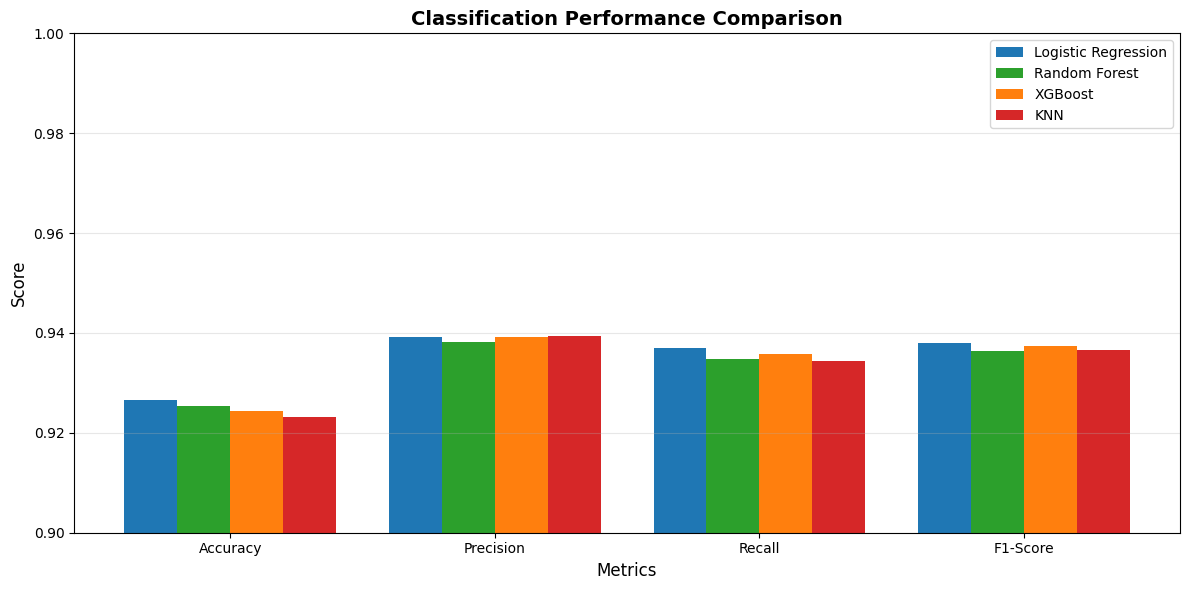

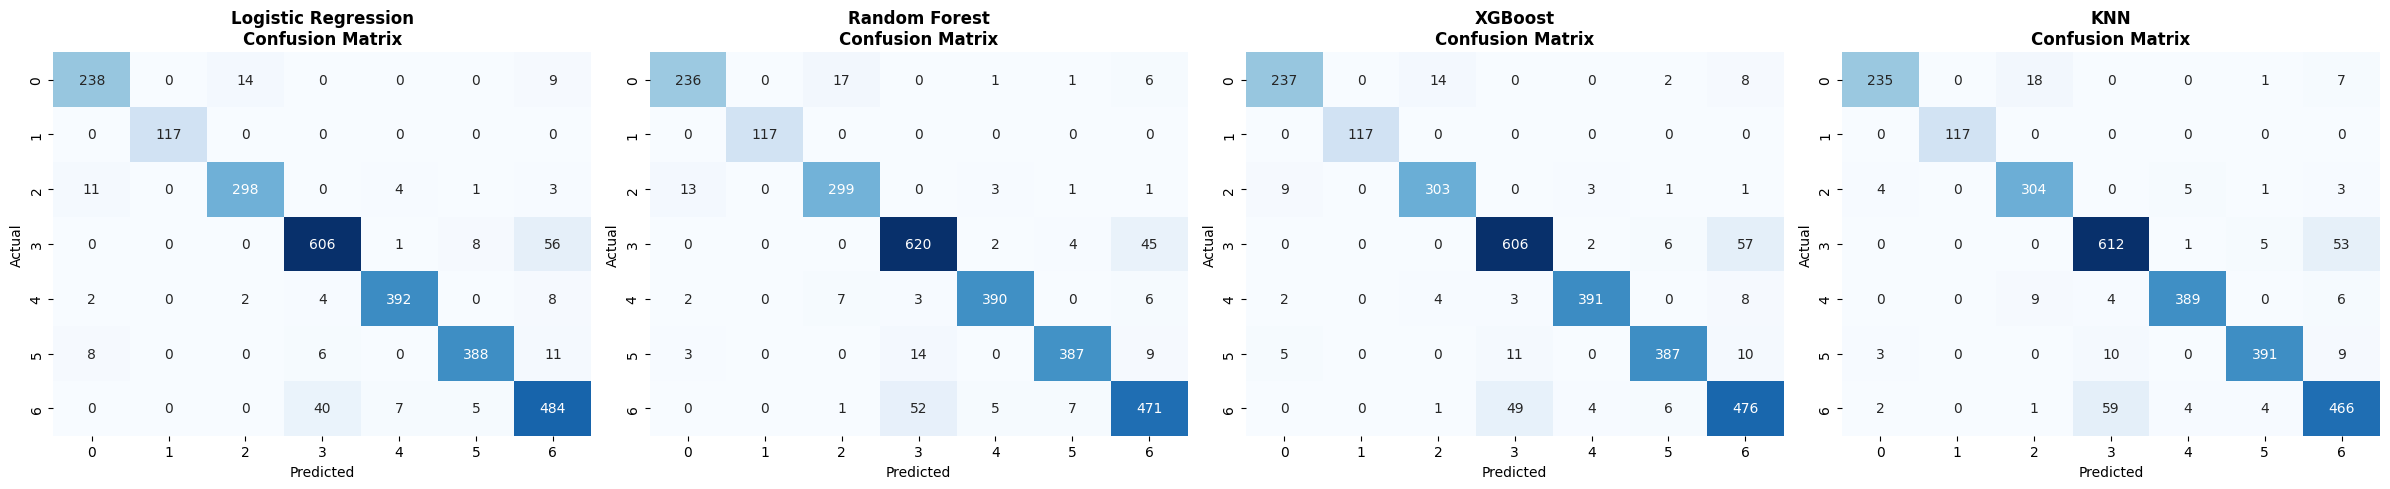

In [19]:
classification_summary = pd.DataFrame({
    'Classifier': ['Logistic Regression', 'Random Forest', 'XGBoost', 'KNN'],
    'Accuracy': [results[name]['accuracy'] for name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'KNN']],
    'Precision': [results[name]['precision'] for name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'KNN']],
    'Recall': [results[name]['recall'] for name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'KNN']],
    'F1-Score': [results[name]['f1'] for name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'KNN']]
})

print(classification_summary.to_string(index=False))

plt.figure(figsize=(12, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.20

classifiers_list = ['Logistic Regression', 'Random Forest', 'XGBoost', 'KNN']
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

for i, name in enumerate(classifiers_list):
    values = [results[name]['accuracy'], results[name]['precision'], results[name]['recall'], results[name]['f1']]
    plt.bar(x + i*width, values, width, label=name, color=colors[i])

plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Classification Performance Comparison', fontsize=14, fontweight='bold')
plt.xticks(x + 1.5*width, metrics)
plt.legend()
plt.ylim([0.9, 1.0])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for idx, name in enumerate(classifiers_list):
    cm = results[name]['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [37]:
classifiers_list = ['Logistic Regression', 'Random Forest', 'XGBoost', 'KNN']

for name in classifiers_list:
    cm = results[name]['confusion_matrix']
    
    print(f"{name}: \n")
    
    num_classes = cm.shape[0]
    
    print(f"{'Class':<10} {'TP':<8} {'FP':<8} {'FN':<8} {'TN':<8}")
    print("-" * 42)
    
    for class_idx in range(num_classes):
        tp = cm[class_idx, class_idx]
        
        fp = cm[:, class_idx].sum() - tp
        
        fn = cm[class_idx, :].sum() - tp
        
        tn = cm.sum() - tp - fp - fn
        
        print(f"{class_idx:<10} {tp:<8} {fp:<8} {fn:<8} {tn:<8}")
    print("\n")

Logistic Regression: 

Class      TP       FP       FN       TN      
------------------------------------------
0          238      21       23       2441    
1          117      0        0        2606    
2          298      16       19       2390    
3          606      50       65       2002    
4          392      12       16       2303    
5          388      14       25       2296    
6          484      87       52       2100    


Random Forest: 

Class      TP       FP       FN       TN      
------------------------------------------
0          236      18       25       2444    
1          117      0        0        2606    
2          299      25       18       2381    
3          620      69       51       1983    
4          390      11       18       2304    
5          387      13       26       2297    
6          471      67       65       2120    


XGBoost: 

Class      TP       FP       FN       TN      
------------------------------------------
0          237   

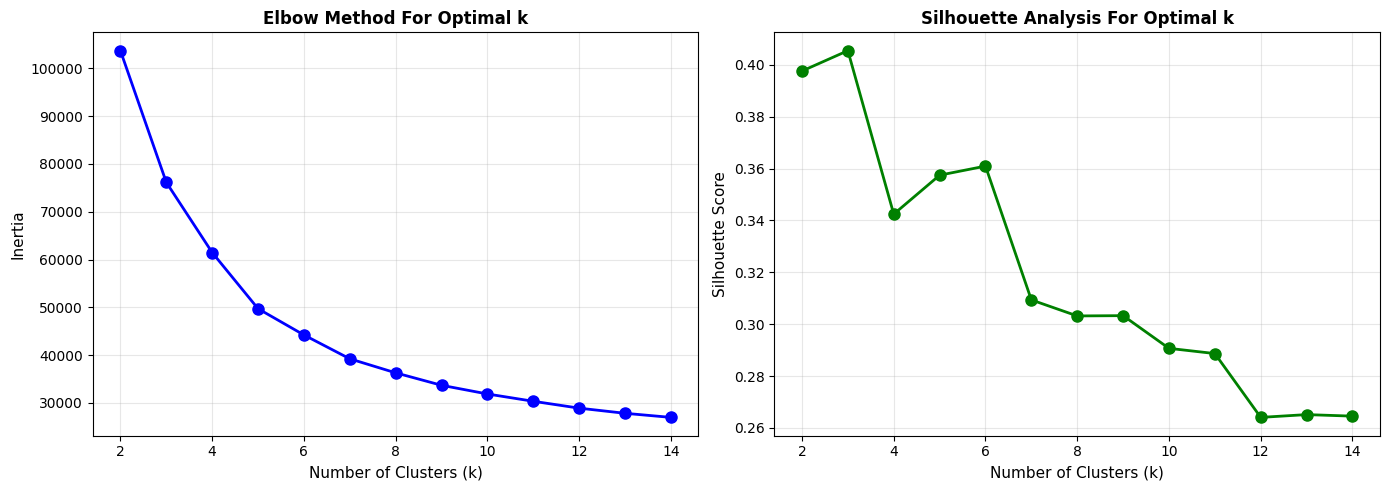


Optimal number of clusters: 3
Silhouette Score at k=3: 0.405


In [20]:
k_range = range(2, 15)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_title('Elbow Method For Optimal k', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Analysis For Optimal k', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters: {optimal_k}")
print(f"Silhouette Score at k={optimal_k}: {max(silhouette_scores):.3f}")

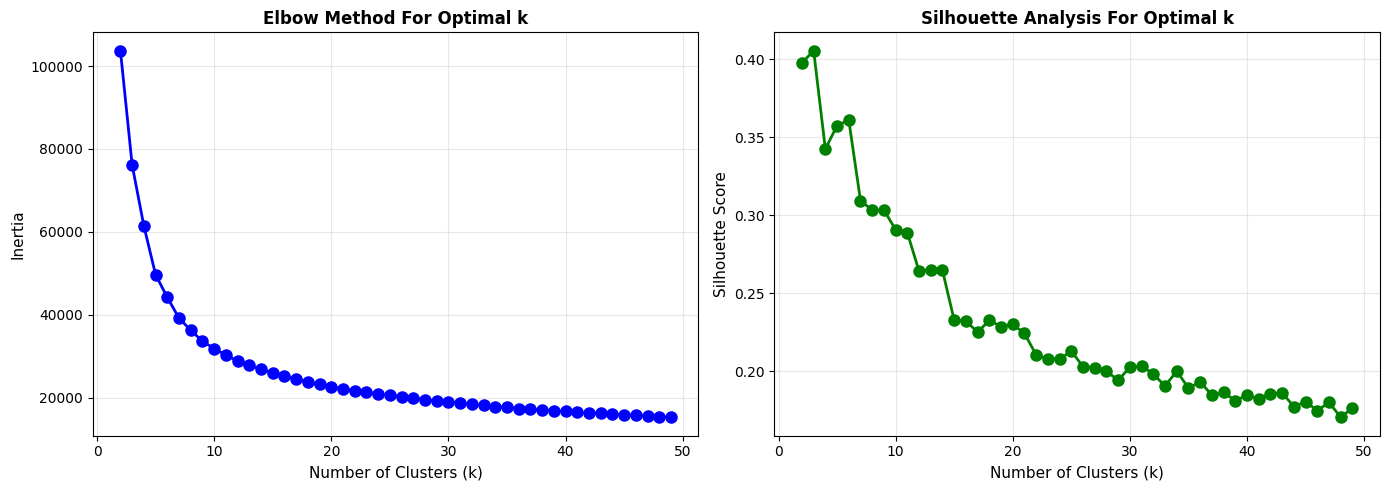


Optimal number of clusters: 3
Silhouette Score at k=3: 0.405


In [30]:
k_range = range(2, 50)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_title('Elbow Method For Optimal k', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Analysis For Optimal k', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters: {optimal_k}")
print(f"Silhouette Score at k={optimal_k}: {max(silhouette_scores):.3f}")

In [22]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_train_scaled)

kmeans_silhouette = silhouette_score(X_train_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y_train, kmeans_labels)
kmeans_nmi = normalized_mutual_info_score(y_train, kmeans_labels)

print(f"\nK-Means (k=3) Metrics:")
# Internal Measures
print(f"Adjusted Rand Index (vs true labels): {kmeans_ari:.3f}")
print(f"Normalized Mutual Information (vs true labels): {kmeans_nmi:.3f}")


kmeans_ch = calinski_harabasz_score(X_train_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_train_scaled, kmeans_labels)
# External Measures
print(f"Silhouette Score: {kmeans_silhouette:.3f}")
print(f"Calinski-Harabasz Score (higher is better): {kmeans_ch:.3f}")
print(f"Davies-Bouldin Score (lower is better): {kmeans_db:.3f}")

clustering_results = {
    'K-Means': {
        'model': kmeans,
        'labels': kmeans_labels,
        'silhouette': kmeans_silhouette,
        'ari': kmeans_ari,
        'nmi': kmeans_nmi,
        'ch_score': kmeans_ch,
        'db_score': kmeans_db
    }
}


K-Means (k=3) Metrics:
Adjusted Rand Index (vs true labels): 0.299
Normalized Mutual Information (vs true labels): 0.485
Silhouette Score: 0.405
Calinski-Harabasz Score (higher is better): 7008.771
Davies-Bouldin Score (lower is better): 0.899


In [23]:
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_train_scaled)

kmeans_silhouette = silhouette_score(X_train_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y_train, kmeans_labels)
kmeans_nmi = normalized_mutual_info_score(y_train, kmeans_labels)

print(f"\nK-Means (k=7) Metrics:")
# Internal Measures
print(f"Adjusted Rand Index (vs true labels): {kmeans_ari:.3f}")
print(f"Normalized Mutual Information (vs true labels): {kmeans_nmi:.3f}")


kmeans_ch = calinski_harabasz_score(X_train_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_train_scaled, kmeans_labels)
# External Measures
print(f"Silhouette Score: {kmeans_silhouette:.3f}")
print(f"Calinski-Harabasz Score (higher is better): {kmeans_ch:.3f}")
print(f"Davies-Bouldin Score (lower is better): {kmeans_db:.3f}")

clustering_results = {
    'K-Means': {
        'model': kmeans,
        'labels': kmeans_labels,
        'silhouette': kmeans_silhouette,
        'ari': kmeans_ari,
        'nmi': kmeans_nmi,
        'ch_score': kmeans_ch,
        'db_score': kmeans_db
    }
}


K-Means (k=7) Metrics:
Adjusted Rand Index (vs true labels): 0.664
Normalized Mutual Information (vs true labels): 0.710
Silhouette Score: 0.309
Calinski-Harabasz Score (higher is better): 6238.775
Davies-Bouldin Score (lower is better): 1.098


In [24]:
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_train_scaled)

hier_silhouette = silhouette_score(X_train_scaled, hierarchical_labels)
hier_ari = adjusted_rand_score(y_train, hierarchical_labels)
hier_nmi = normalized_mutual_info_score(y_train, hierarchical_labels)
hier_ch = calinski_harabasz_score(X_train_scaled, hierarchical_labels)
hier_db = davies_bouldin_score(X_train_scaled, hierarchical_labels)

print(f"\nHierarchical Clustering (k=3) Metrics:")
# Internal Measures
print(f"Silhouette Score: {hier_silhouette:.3f}")
print(f"Calinski-Harabasz Score (higher is better): {hier_ch:.3f}")
print(f"Davies-Bouldin Score (lower is better): {hier_db:.3f}")
# External Measures
print(f"Adjusted Rand Index (vs true labels): {hier_ari:.3f}")
print(f"Normalized Mutual Information (vs true labels): {hier_nmi:.3f}")

clustering_results['Hierarchical Clustering'] = {
    'model': hierarchical,
    'labels': hierarchical_labels,
    'silhouette': hier_silhouette,
    'ari': hier_ari,
    'nmi': hier_nmi,
    'ch_score': hier_ch,
    'db_score': hier_db
}


Hierarchical Clustering (k=3) Metrics:
Silhouette Score: 0.406
Calinski-Harabasz Score (higher is better): 6592.659
Davies-Bouldin Score (lower is better): 0.925
Adjusted Rand Index (vs true labels): 0.332
Normalized Mutual Information (vs true labels): 0.547


In [25]:
hierarchical = AgglomerativeClustering(n_clusters=7, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_train_scaled)

hier_silhouette = silhouette_score(X_train_scaled, hierarchical_labels)
hier_ari = adjusted_rand_score(y_train, hierarchical_labels)
hier_nmi = normalized_mutual_info_score(y_train, hierarchical_labels)
hier_ch = calinski_harabasz_score(X_train_scaled, hierarchical_labels)
hier_db = davies_bouldin_score(X_train_scaled, hierarchical_labels)

print(f"\nHierarchical Clustering (k=7) Metrics:")
# Internal Measures
print(f"Silhouette Score: {hier_silhouette:.3f}")
print(f"Calinski-Harabasz Score (higher is better): {hier_ch:.3f}")
print(f"Davies-Bouldin Score (lower is better): {hier_db:.3f}")
# External Measures
print(f"Adjusted Rand Index (vs true labels): {hier_ari:.3f}")
print(f"Normalized Mutual Information (vs true labels): {hier_nmi:.3f}")


clustering_results['Hierarchical Clustering'] = {
    'model': hierarchical,
    'labels': hierarchical_labels,
    'silhouette': hier_silhouette,
    'ari': hier_ari,
    'nmi': hier_nmi,
    'ch_score': hier_ch,
    'db_score': hier_db
}


Hierarchical Clustering (k=7) Metrics:
Silhouette Score: 0.279
Calinski-Harabasz Score (higher is better): 5517.311
Davies-Bouldin Score (lower is better): 1.137
Adjusted Rand Index (vs true labels): 0.639
Normalized Mutual Information (vs true labels): 0.719


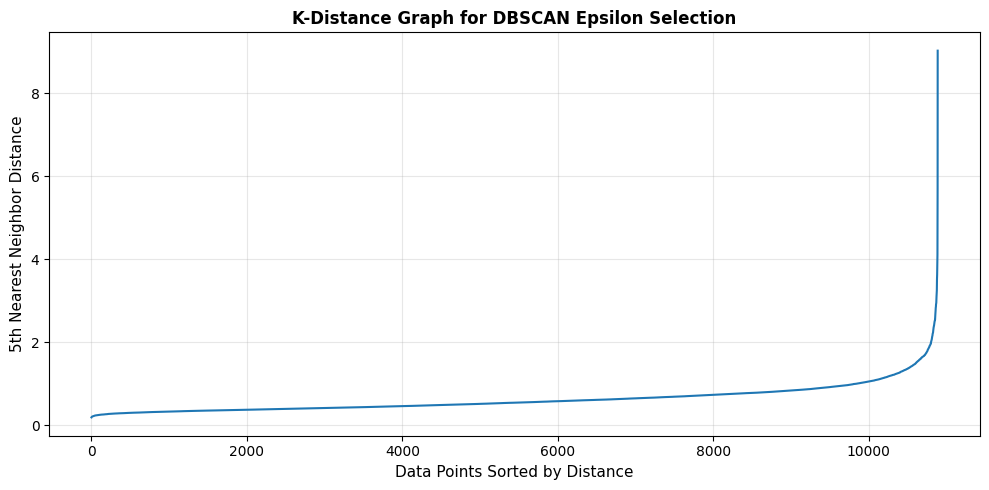


DBSCAN (eps=1.0, min_samples=5) Results:
Number of clusters found: 7
Number of noise points: 643
Silhouette Score: -0.024
Calinski-Harabasz Score (higher is better): 450.258
Davies-Bouldin Score (lower is better): 1.926
Adjusted Rand Index (vs true labels): 0.039
Normalized Mutual Information (vs true labels): 0.138


In [26]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_train_scaled)
distances, indices = neighbors_fit.kneighbors(X_train_scaled)
distances = np.sort(distances[:, -1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.xlabel('Data Points Sorted by Distance', fontsize=11)
plt.ylabel('5th Nearest Neighbor Distance', fontsize=11)
plt.title('K-Distance Graph for DBSCAN Epsilon Selection', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

eps_value = 1.0
dbscan = DBSCAN(eps=eps_value, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_train_scaled)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nDBSCAN (eps={eps_value}, min_samples=5) Results:")
print(f"Number of clusters found: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise}")

dbscan_silhouette = silhouette_score(X_train_scaled, dbscan_labels)
dbscan_ari = adjusted_rand_score(y_train, dbscan_labels)
dbscan_nmi = normalized_mutual_info_score(y_train, dbscan_labels)
dbscan_ch = calinski_harabasz_score(X_train_scaled, dbscan_labels)
dbscan_db = davies_bouldin_score(X_train_scaled, dbscan_labels)

print(f"Silhouette Score: {dbscan_silhouette:.3f}")
print(f"Calinski-Harabasz Score (higher is better): {dbscan_ch:.3f}")
print(f"Davies-Bouldin Score (lower is better): {dbscan_db:.3f}")
print(f"Adjusted Rand Index (vs true labels): {dbscan_ari:.3f}")
print(f"Normalized Mutual Information (vs true labels): {dbscan_nmi:.3f}")

clustering_results['DBSCAN'] = {
    'model': dbscan,
    'labels': dbscan_labels,
    'silhouette': dbscan_silhouette,
    'ari': dbscan_ari,
    'nmi': dbscan_nmi,
    'ch_score': dbscan_ch,
    'db_score': dbscan_db,
    'n_clusters': n_clusters_dbscan,
    'n_noise': n_noise
}


      Clustering Method  Silhouette Score  Adjusted Rand Index  Normalized Mutual Info  Calinski-Harabasz
                K-Means          0.309353             0.664016                0.710210        6238.774975
Hierarchical Clustering          0.278805             0.638736                0.718691        5517.310680
                 DBSCAN         -0.023945             0.038719                0.137516         450.258481


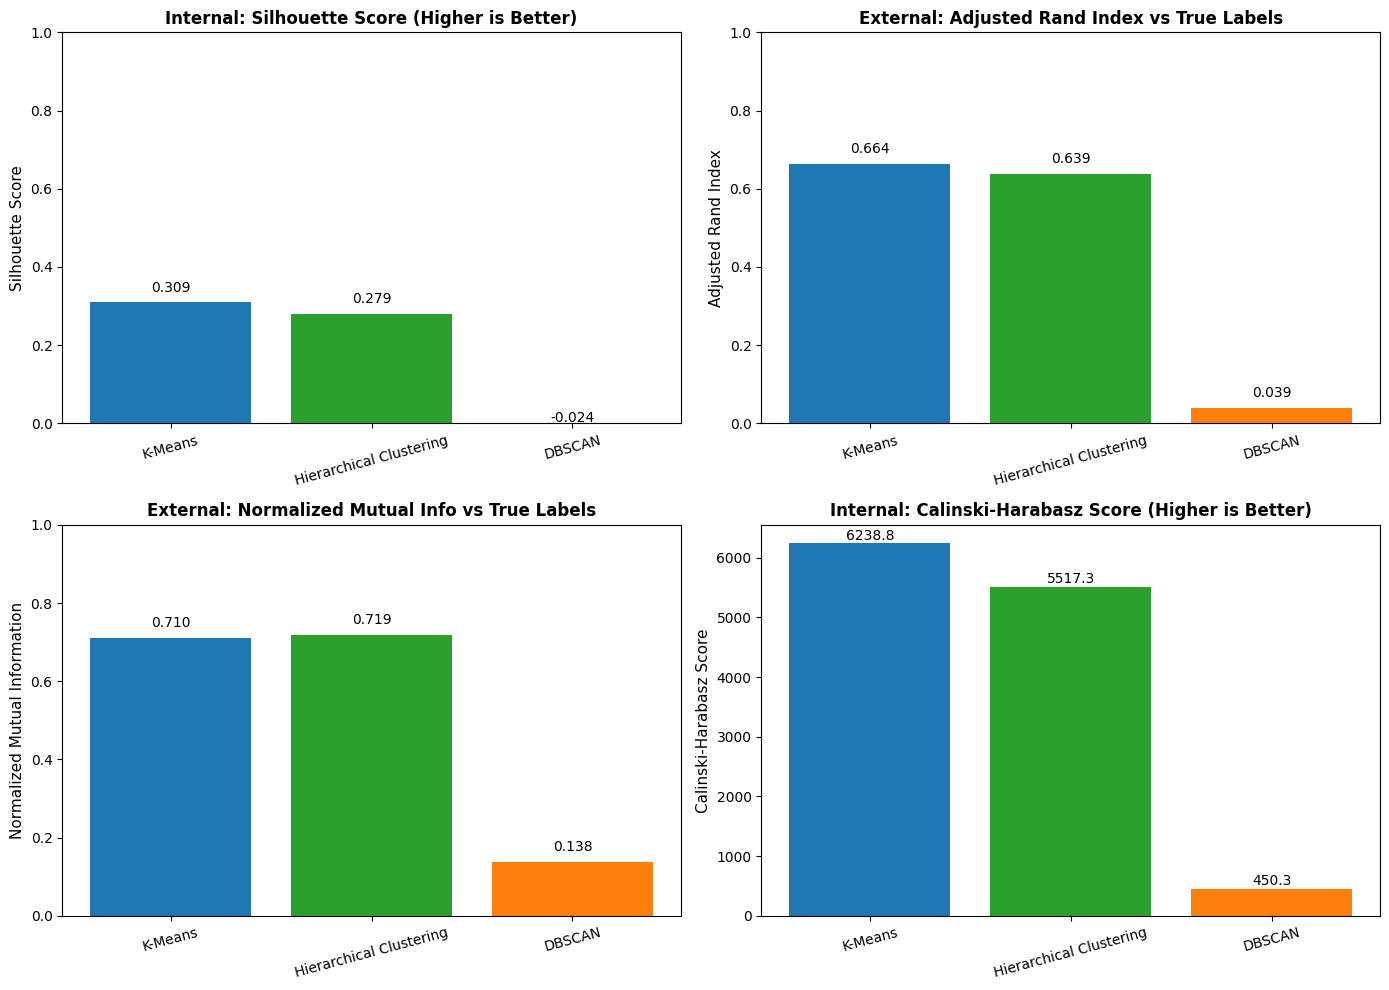

In [27]:
clustering_summary = pd.DataFrame({
    'Clustering Method': ['K-Means', 'Hierarchical Clustering', 'DBSCAN'],
    'Silhouette Score': [
        clustering_results['K-Means']['silhouette'],
        clustering_results['Hierarchical Clustering']['silhouette'],
        clustering_results['DBSCAN']['silhouette']
    ],
    'Adjusted Rand Index': [
        clustering_results['K-Means']['ari'],
        clustering_results['Hierarchical Clustering']['ari'],
        clustering_results['DBSCAN']['ari']
    ],
    'Normalized Mutual Info': [
        clustering_results['K-Means']['nmi'],
        clustering_results['Hierarchical Clustering']['nmi'],
        clustering_results['DBSCAN']['nmi']
    ],
    'Calinski-Harabasz': [
        clustering_results['K-Means']['ch_score'],
        clustering_results['Hierarchical Clustering']['ch_score'],
        clustering_results['DBSCAN']['ch_score']
    ]
})

print("\n" + clustering_summary.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

methods = ['K-Means', 'Hierarchical Clustering', 'DBSCAN']
colors_cluster = ['#1f77b4', '#2ca02c', '#ff7f0e']

# Silhouette Score
ax = axes[0, 0]
silhouette_vals = [clustering_results[m]['silhouette'] for m in methods]
ax.bar(methods, silhouette_vals, color=colors_cluster)
ax.set_ylabel('Silhouette Score', fontsize=11)
ax.set_title('Internal: Silhouette Score (Higher is Better)', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
for i, v in enumerate(silhouette_vals):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=10)
ax.tick_params(axis='x', rotation=15)

# Adjusted Rand Index
ax = axes[0, 1]
ari_vals = [clustering_results[m]['ari'] for m in methods]
ax.bar(methods, ari_vals, color=colors_cluster)
ax.set_ylabel('Adjusted Rand Index', fontsize=11)
ax.set_title('External: Adjusted Rand Index vs True Labels', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
for i, v in enumerate(ari_vals):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=10)
ax.tick_params(axis='x', rotation=15)

# Normalized Mutual Information
ax = axes[1, 0]
nmi_vals = [clustering_results[m]['nmi'] for m in methods]
ax.bar(methods, nmi_vals, color=colors_cluster)
ax.set_ylabel('Normalized Mutual Information', fontsize=11)
ax.set_title('External: Normalized Mutual Info vs True Labels', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
for i, v in enumerate(nmi_vals):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=10)
ax.tick_params(axis='x', rotation=15)

# Calinski-Harabasz Score
ax = axes[1, 1]
ch_vals = [clustering_results[m]['ch_score'] for m in methods]
ax.bar(methods, ch_vals, color=colors_cluster)
ax.set_ylabel('Calinski-Harabasz Score', fontsize=11)
ax.set_title('Internal: Calinski-Harabasz Score (Higher is Better)', fontsize=12, fontweight='bold')
for i, v in enumerate(ch_vals):
    ax.text(i, v + 10, f'{v:.1f}', ha='center', va='bottom', fontsize=10)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

PCA Variance Explained: 0.819


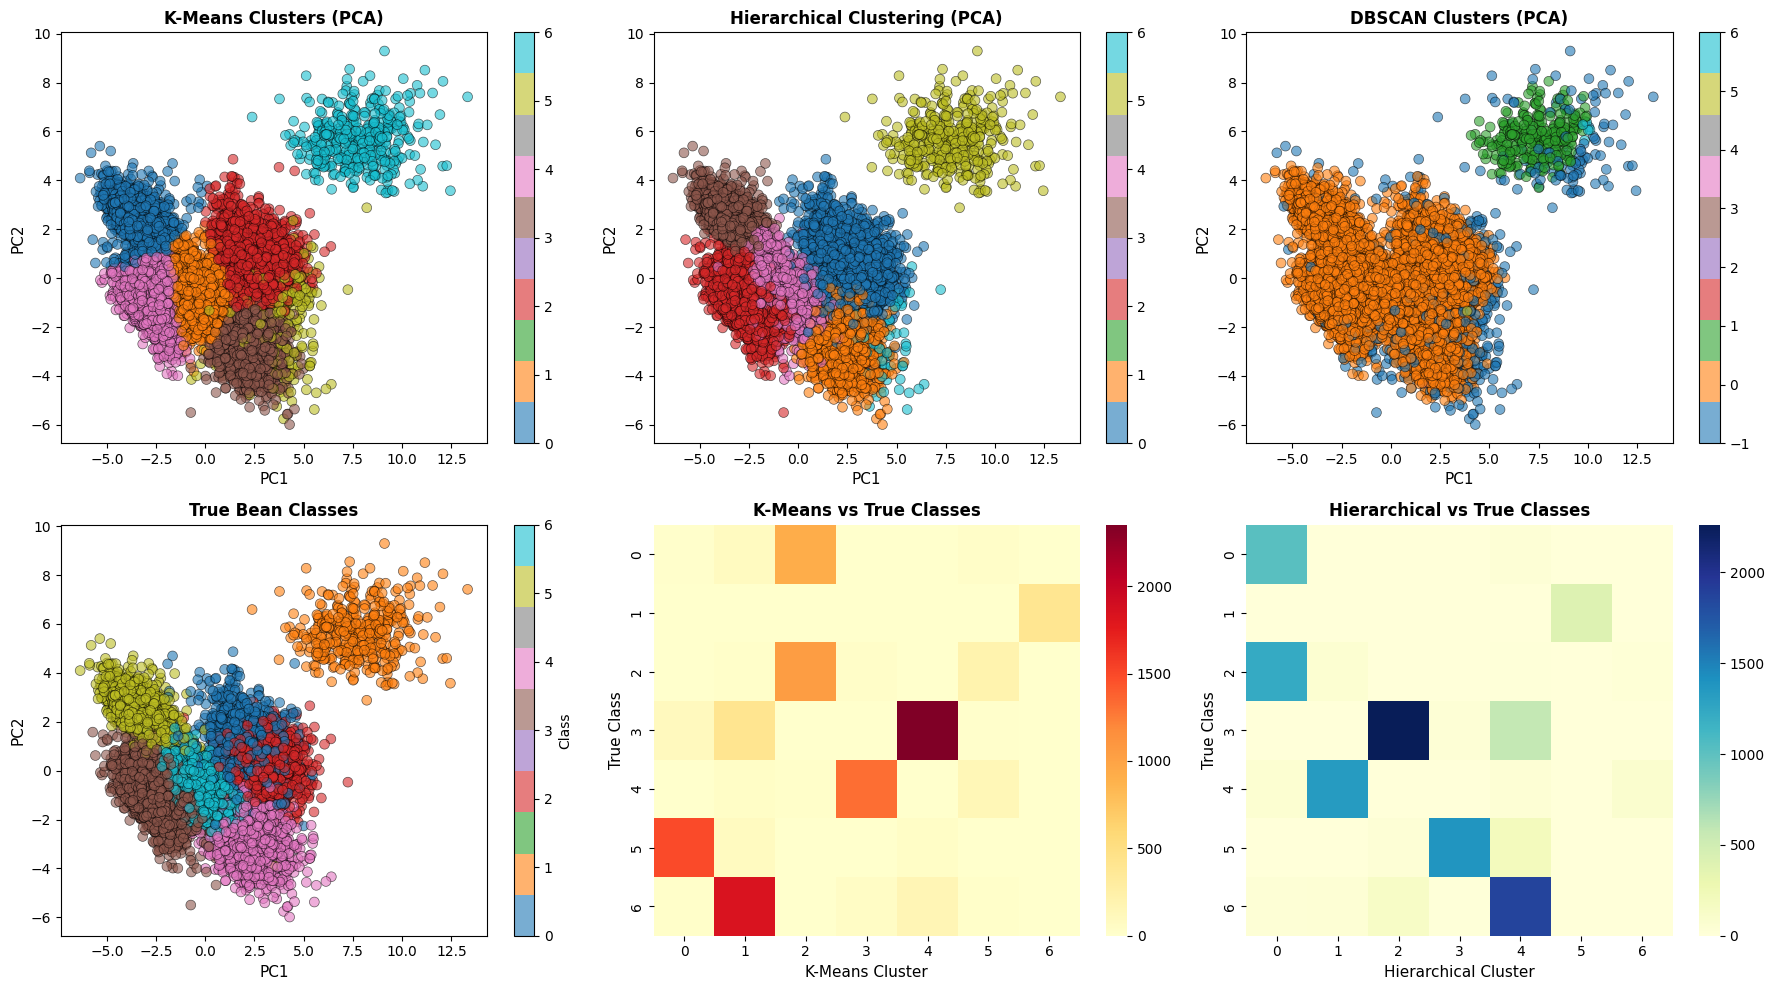

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

print(f"PCA Variance Explained: {pca.explained_variance_ratio_.sum():.3f}")

y_train_numeric = pd.Categorical(y_train).codes

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# K-Means
ax = axes[0, 0]
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=clustering_results['K-Means']['labels'], 
                     cmap='tab10', s=50, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.set_xlabel('PC1', fontsize=11)
ax.set_ylabel('PC2', fontsize=11)
ax.set_title('K-Means Clusters (PCA)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax)

# Hierarchical
ax = axes[0, 1]
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=clustering_results['Hierarchical Clustering']['labels'], 
                     cmap='tab10', s=50, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.set_xlabel('PC1', fontsize=11)
ax.set_ylabel('PC2', fontsize=11)
ax.set_title('Hierarchical Clustering (PCA)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax)

# DBSCAN
ax = axes[0, 2]
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=clustering_results['DBSCAN']['labels'], 
                     cmap='tab10', s=50, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.set_xlabel('PC1', fontsize=11)
ax.set_ylabel('PC2', fontsize=11)
ax.set_title('DBSCAN Clusters (PCA)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax)

# True classes
ax = axes[1, 0]
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_numeric, 
                     cmap='tab10', s=50, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.set_xlabel('PC1', fontsize=11)
ax.set_ylabel('PC2', fontsize=11)
ax.set_title('True Bean Classes', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Class')

# Contingency table heatmaps
# K-Means vs true classes
ax = axes[1, 1]
cm_kmeans = confusion_matrix(y_train_numeric, clustering_results['K-Means']['labels'])
sns.heatmap(cm_kmeans, annot=False, fmt='d', cmap='YlOrRd', ax=ax, cbar=True)
ax.set_xlabel('K-Means Cluster', fontsize=11)
ax.set_ylabel('True Class', fontsize=11)
ax.set_title('K-Means vs True Classes', fontsize=12, fontweight='bold')

# Hierarchical vs true classes
ax = axes[1, 2]
cm_hier = confusion_matrix(y_train_numeric, clustering_results['Hierarchical Clustering']['labels'])    
sns.heatmap(cm_hier, annot=False, fmt='d', cmap='YlGnBu', ax=ax, cbar=True)
ax.set_xlabel('Hierarchical Cluster', fontsize=11)
ax.set_ylabel('True Class', fontsize=11)
ax.set_title('Hierarchical vs True Classes', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [29]:
# ============================================================================
# COMPREHENSIVE RESULTS TABLE: CLASSIFICATION vs CLUSTERING
# ============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE RESULTS: CLASSIFICATION vs CLUSTERING")
print("="*80)

# Classification results
class_results = []
# Added 'KNN' to the list of classifiers below
for name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'KNN']:
    class_results.append({
        'Model/Method': name,
        'Type': 'Classification',
        'Accuracy/Silhouette': results[name]['accuracy'],
        'Precision/ARI': results[name]['precision'],
        'Recall/NMI': results[name]['recall'],
        'F1/CH Score': results[name]['f1']
    })

# Clustering results
cluster_results = []
for name in ['K-Means', 'Hierarchical Clustering', 'DBSCAN']:
    cluster_results.append({
        'Model/Method': name,
        'Type': 'Clustering',
        'Accuracy/Silhouette': clustering_results[name]['silhouette'],
        'Precision/ARI': clustering_results[name]['ari'],
        'Recall/NMI': clustering_results[name]['nmi'],
        'F1/CH Score': clustering_results[name]['ch_score']
    })

# Combine all results
all_results = class_results + cluster_results
comprehensive_table = pd.DataFrame(all_results)

print("\n" + comprehensive_table.to_string(index=False))

# Export results to CSV for reference
comprehensive_table.to_csv('classification_clustering_results.csv', index=False)
print("\nResults exported to 'classification_clustering_results.csv'")


COMPREHENSIVE RESULTS: CLASSIFICATION vs CLUSTERING

           Model/Method           Type  Accuracy/Silhouette  Precision/ARI  Recall/NMI  F1/CH Score
    Logistic Regression Classification             0.926552       0.939264    0.936901     0.937908
          Random Forest Classification             0.925450       0.938194    0.934727     0.936352
                XGBoost Classification             0.924348       0.939110    0.935779     0.937306
                    KNN Classification             0.923246       0.939486    0.934430     0.936673
                K-Means     Clustering             0.309353       0.664016    0.710210  6238.774975
Hierarchical Clustering     Clustering             0.278805       0.638736    0.718691  5517.310680
                 DBSCAN     Clustering            -0.023945       0.038719    0.137516   450.258481

Results exported to 'classification_clustering_results.csv'
